1) Сгенирируйте в python равномерное распределение и постройте для него ящик с усами.

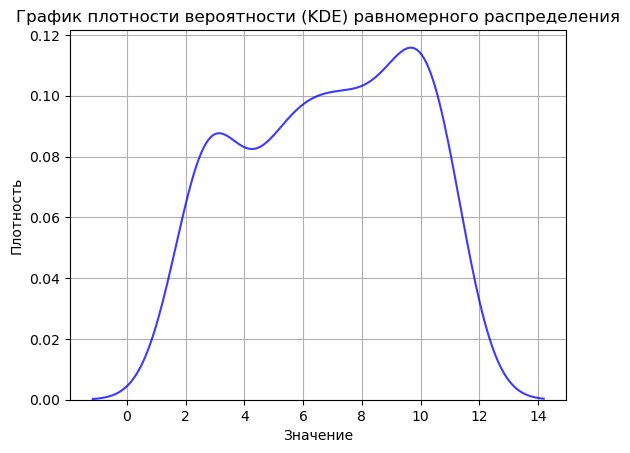

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = np.random.uniform(low=2, high=11, size=125)

sns.kdeplot(data, color='blue', alpha=0.77)
plt.title("График плотности вероятности (KDE) равномерного распределения")
plt.xlabel("Значение")
plt.ylabel("Плотность")
plt.grid(True)
plt.show()


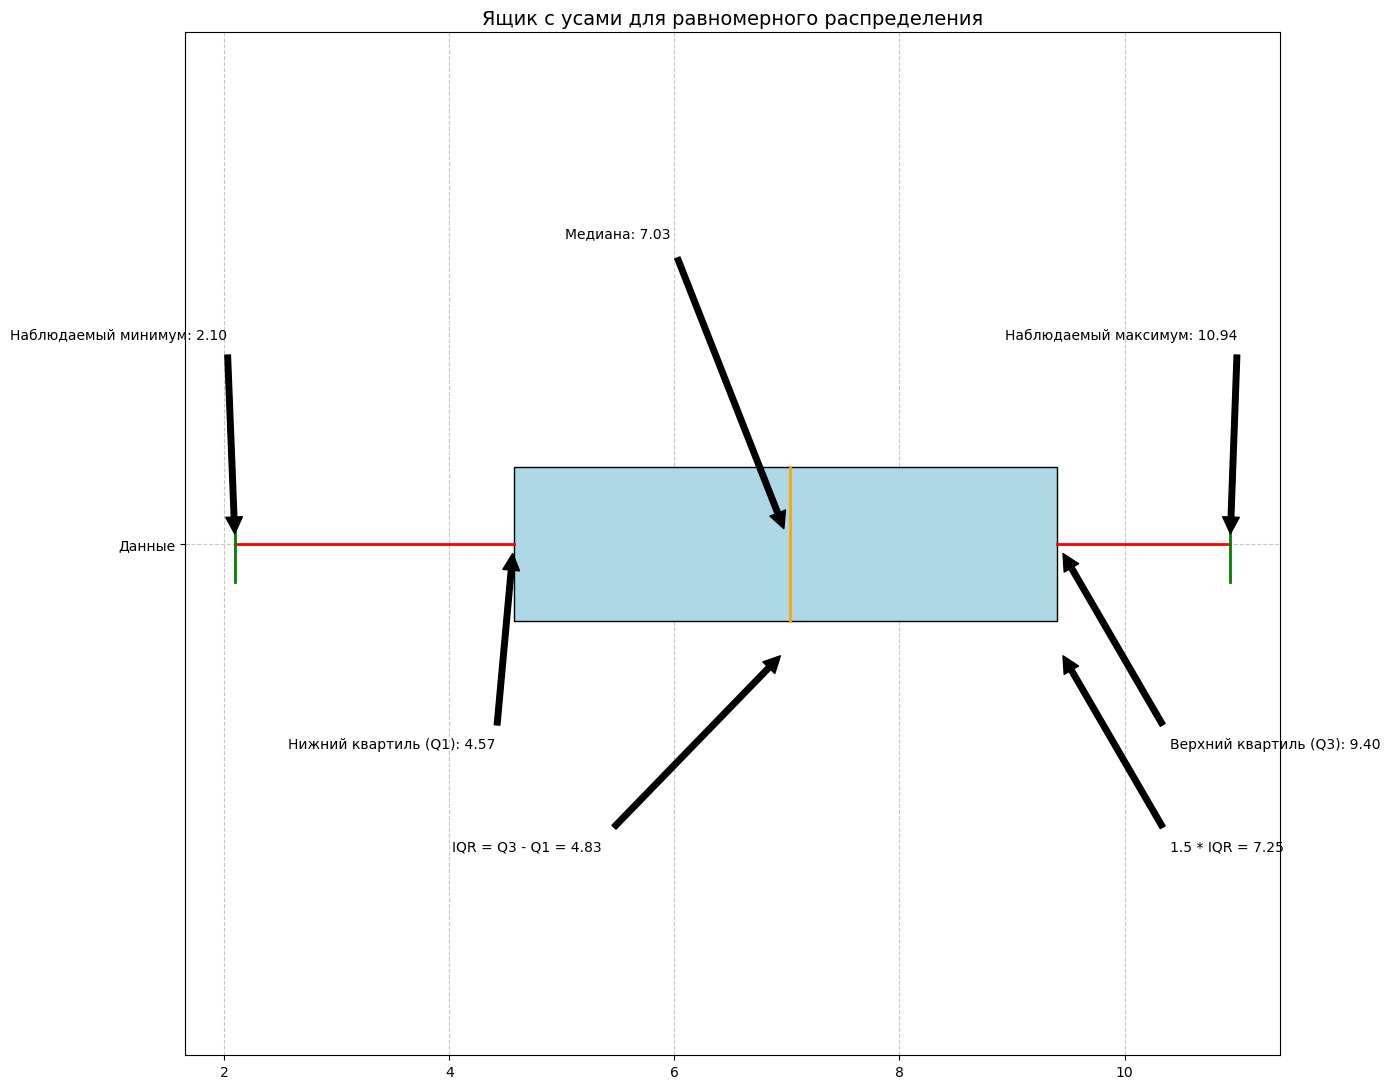

In [9]:
# Создание boxplot
plt.figure(figsize=(14, 11))
boxplot = plt.boxplot(data, vert=False, patch_artist=True)

colors = ['lightblue', 'red', 'green', 'orange', 'purple', 'brown']
boxplot['boxes'][0].set_facecolor(colors[0])
for whisker in boxplot['whiskers']:
    whisker.set(color=colors[1], linewidth=2)
for cap in boxplot['caps']:
    cap.set(color=colors[2], linewidth=2)
for median in boxplot['medians']:
    median.set(color=colors[3], linewidth=2)
for flier in boxplot['fliers']:
    flier.set(marker='o', color=colors[4], alpha=0.5)

# Вычисление характеристик
q1 = np.percentile(data, 25)
median = np.median(data)
q3 = np.percentile(data, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
min_val = np.min(data)
max_val = np.max(data)
lower_whisker = max(min_val, lower_bound)
upper_whisker = min(max_val, upper_bound)

plt.annotate(f'Наблюдаемый минимум: {min_val:.2f}', xy=(min_val, 1), xytext=(min_val - 2, 1.2),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Нижний квартиль (Q1): {q1:.2f}', xy=(q1, 1), xytext=(q1 - 2, 0.8),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Медиана: {median:.2f}', xy=(median, 1), xytext=(median - 2, 1.3),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Верхний квартиль (Q3): {q3:.2f}', xy=(q3, 1), xytext=(q3 + 1, 0.8),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Наблюдаемый максимум: {max_val:.2f}', xy=(max_val, 1), xytext=(max_val - 2, 1.2),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'IQR = Q3 - Q1 = {iqr:.2f}', xy=(median, 0.9), xytext=(median - 3, 0.7),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'1.5 * IQR = {1.5 * iqr:.2f}', xy=(q3, 0.9), xytext=(q3 + 1, 0.7),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Ящик с усами для равномерного распределения', fontsize=14)
plt.yticks([1], ['Данные'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()